<a href="https://colab.research.google.com/github/Brandon9010/Brandon9010/blob/main/02_predictive_inventory_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predictive Model

Import Libraries and Load data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Ingest Data Directly from GitHub (RAW URLs)

products_url = 'https://raw.githubusercontent.com/Brandon9010/Brandon9010/main/Pool_Inventory_Forecasting/pool_products_master.csv'
sales_url = 'https://raw.githubusercontent.com/Brandon9010/Brandon9010/main/Pool_Inventory_Forecasting/pool_sales_history.csv'

df_products = pd.read_csv(products_url)
df_sales = pd.read_csv(sales_url)

# Ensure dates are parsed correctly
df_sales['Transaction_Date'] = pd.to_datetime(df_sales['Transaction_Date'])

print("Cloud Data ingestion successful!")
print(f"Products Loaded: {df_products.shape[0]} SKUs")
print(f"Sales History Loaded: {df_sales.shape[0]} transactions")

# Preview the joined dataset to verify relational architecture
df_merged = pd.merge(df_sales, df_products, on='SKU', how='left')
df_merged.head()

Cloud Data ingestion successful!
Products Loaded: 27 SKUs
Sales History Loaded: 20654 transactions


,Transaction_Date,SKU,Unit_Qty_Sold,Product_Name,Category,Brand,Distributor,Unit_Size,Case_Qty,Case_Cost,Unit_Cost,Unit_Retail
0,2021-01-01 12:35:00,INT-CA-32OZ,1,InTheSwim Copper Algaecide (32oz),Copper Algaecide,InTheSwim,AquaClear Wholesalers,32oz,12,113.62,9.47,19.16
1,2021-01-01 08:43:00,CHL-PS-17LB,1,Chlorox Pool Shock (17lb),Pool Shock,Chlorox,Chemical Direct,17lb,1,42.89,42.89,82.29
2,2021-01-02 18:56:00,CHL-PS-1LB,3,Chlorox Pool Shock (1lb),Pool Shock,Chlorox,BioGuard Logistics,1lb,50,189.47,3.79,7.39
3,2021-01-02 16:48:00,INT-CT-25LB,2,InTheSwim Chlorine Tablets (25lb),Chlorine Tablets,InTheSwim,AquaClear Wholesalers,25lb,1,77.30,77.30,158.15
4,2021-01-02 12:49:00,CHL-PS-1LB,4,Chlorox Pool Shock (1lb),Pool Shock,Chlorox,BioGuard Logistics,1lb,50,189.47,3.79,7.39


Exporatory Data Analysis

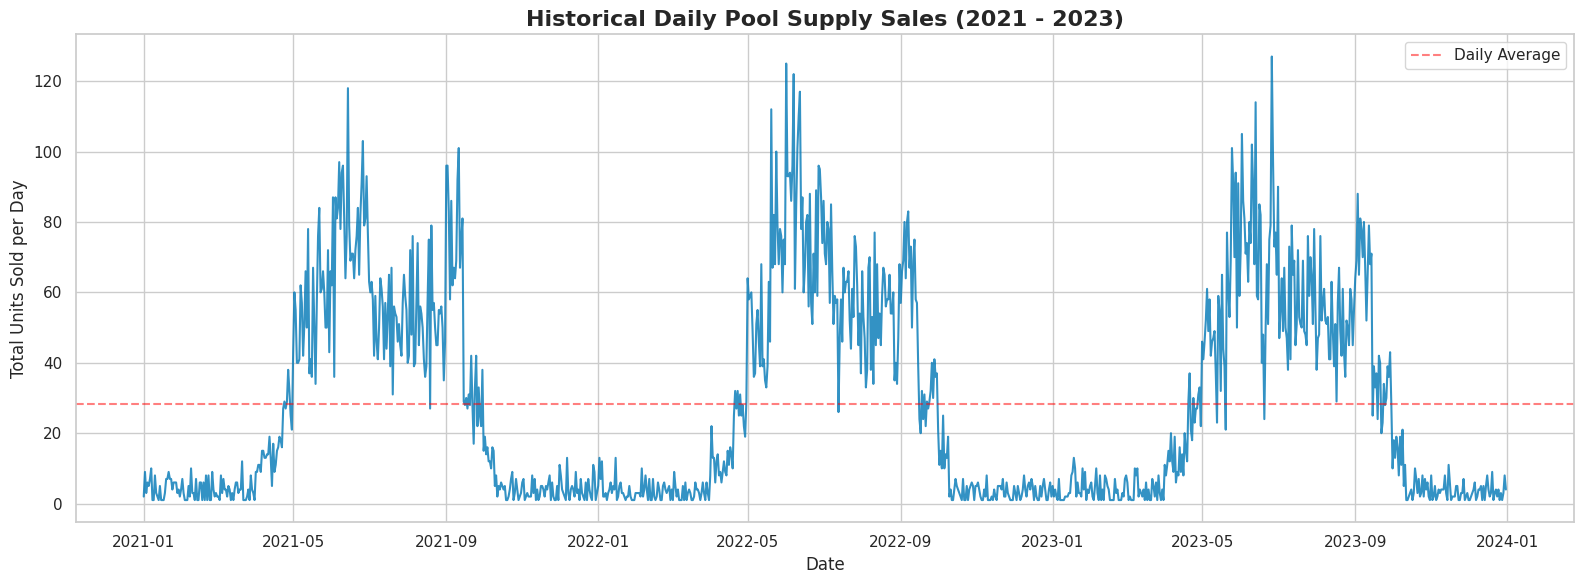

In [6]:
# Group sales by day to see the macro trend
daily_sales = df_sales.groupby(df_sales['Transaction_Date'].dt.date)['Unit_Qty_Sold'].sum().reset_index()
daily_sales['Transaction_Date'] = pd.to_datetime(daily_sales['Transaction_Date'])

plt.figure(figsize=(16, 6))
sns.lineplot(data=daily_sales, x='Transaction_Date', y='Unit_Qty_Sold', color='#0077b6', alpha=0.8)

# Highlight the Summer Seasons
plt.title("Historical Daily Pool Supply Sales (2021 - 2023)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Units Sold per Day", fontsize=12)

# Add some business context annotations for the portfolio
plt.axhline(y=daily_sales['Unit_Qty_Sold'].mean(), color='red', linestyle='--', alpha=0.5, label='Daily Average')
plt.legend()
plt.tight_layout()
plt.show()

Prophet Forecasting

In [7]:
from prophet import Prophet
import math

print(f"Initializing Prophet models for {df_products.shape[0]} SKUs. This will take about 30-60 seconds...")

# 1. Prepare to store our final predictions
forecast_results = []
skus = df_sales['SKU'].unique()

# 2. Loop through every single product to build an individual forecast
for sku in skus:
    # Filter historical data just for this SKU
    sku_data = df_sales[df_sales['SKU'] == sku]

    # Group by day (Prophet requires daily data)
    daily_sku = sku_data.groupby(sku_data['Transaction_Date'].dt.date)['Unit_Qty_Sold'].sum().reset_index()

    # Prophet strictly requires columns to be named 'ds' (datestamp) and 'y' (value)
    df_prophet = daily_sku.rename(columns={'Transaction_Date': 'ds', 'Unit_Qty_Sold': 'y'})

    # Initialize the Prophet Model
    # We turn on yearly seasonality to capture the Summer peaks and Winter dead-zones
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

    # Mute the verbose logs Prophet spits out
    import logging
    logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

    m.fit(df_prophet)

    # Create a dataframe to hold future dates (366 days for 2024)
    future = m.make_future_dataframe(periods=366)

    # Predict!
    forecast = m.predict(future)

    # Filter the forecast to ONLY show 2024
    forecast_2024 = forecast[forecast['ds'].dt.year == 2024]

    # Sum up the predicted daily demand (yhat) for the entire year
    total_2024_demand = forecast_2024['yhat'].sum()

    # Safety catch: Ensure no negative forecasts for slow-moving items in winter
    total_2024_demand = max(0, total_2024_demand)

    forecast_results.append({
        'SKU': sku,
        'Predicted_2024_Unit_Demand': round(total_2024_demand)
    })

# Convert the results into a DataFrame
df_forecast = pd.DataFrame(forecast_results)

# ==========================================
# 3. The Business Logic: Calculating the Bulk Order
# ==========================================
# Merge our predictions back with the master product list
df_recommendation = pd.merge(df_products, df_forecast, on='SKU', how='inner')

# Calculate how many CASES to order (Rounding UP to avoid stockouts)
# e.g., If demand is 43 and Case_Qty is 12, (43/12 = 3.58). math.ceil makes it 4 cases.
df_recommendation['Recommended_Cases_to_Order'] = df_recommendation.apply(
    lambda row: math.ceil(row['Predicted_2024_Unit_Demand'] / row['Case_Qty']), axis=1
)

# Calculate the financial impact (Cost to the business)
df_recommendation['Estimated_Bulk_Cost'] = df_recommendation['Recommended_Cases_to_Order'] * df_recommendation['Case_Cost']

# Sort the final list by highest cost so the business knows where capital is tied up
df_recommendation = df_recommendation.sort_values(by='Estimated_Bulk_Cost', ascending=False).reset_index(drop=True)

print("\n✅ Forecasting Complete! Here is the 2024 Bulk Order Recommendation:")
# Display the final business output
df_recommendation[['Product_Name', 'Predicted_2024_Unit_Demand', 'Case_Qty', 'Recommended_Cases_to_Order', 'Estimated_Bulk_Cost']].head(10)

Initializing Prophet models for 27 SKUs. This will take about 30-60 seconds...

✅ Forecasting Complete! Here is the 2024 Bulk Order Recommendation:


,Product_Name,Predicted_2024_Unit_Demand,Case_Qty,Recommended_Cases_to_Order,Estimated_Bulk_Cost
0,InTheSwim Chlorine Tablets (25lb),1226,1,1226,94769.80
1,Chlorox Chlorine Tablets (21lb),1087,1,1087,67807.06
2,AquaChem Pool Shock (25lb),935,1,935,61149.00
3,Chlorox Pool Shock (17lb),915,1,915,39244.35
4,AquaChem Chlorine Tablets (11lb),905,4,227,30858.38
5,AquaChem Black Algaecide (32oz),1131,12,95,13945.05
6,AquaChem Pool Shock (5lb),906,6,151,13061.50
7,HTH Alkalinity Increaser (11lb),850,4,213,12479.67
8,BioGuard Mustard Algaecide (32oz),1130,12,95,12118.20
9,HTH Stabilizer/Conditioner (5lb),884,6,148,12033.88


Final Visual: Forecast Curve

Generating forecast visualization for the top investment SKU...


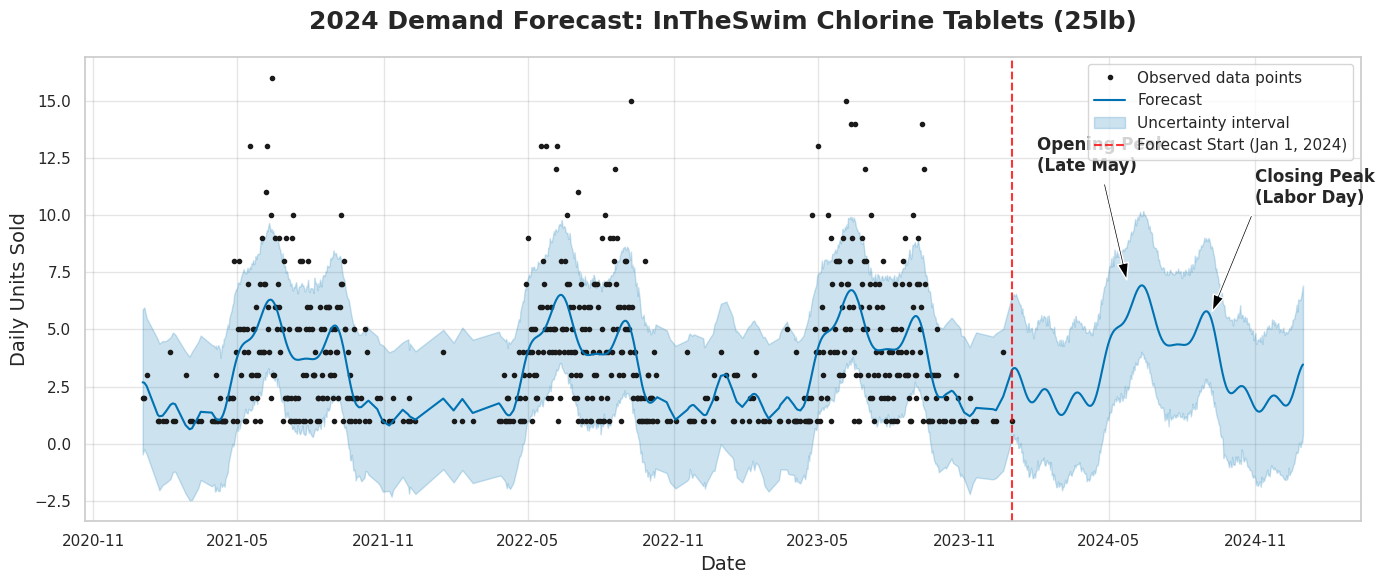

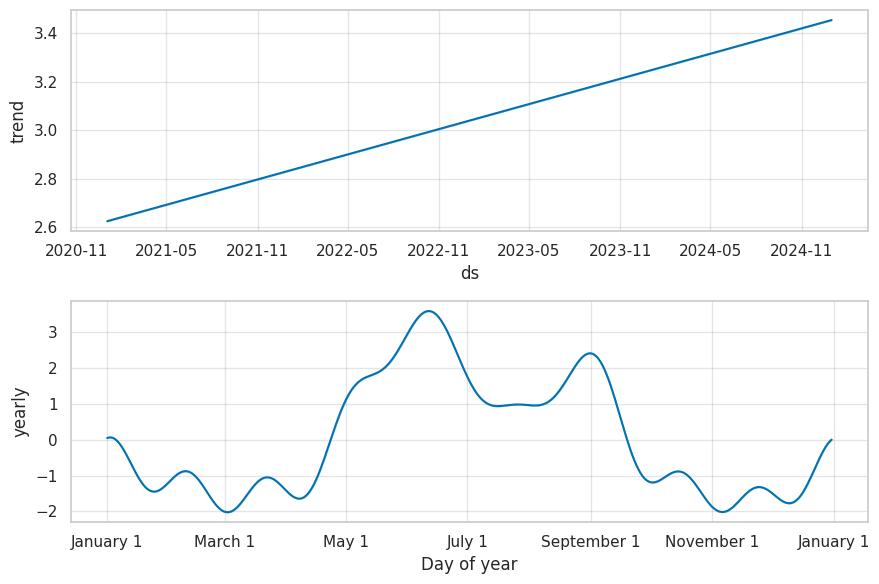

In [9]:
from prophet.plot import plot_plotly, plot_components_plotly
import matplotlib.pyplot as plt

print("Generating forecast visualization for the top investment SKU...")

# 1. Identify the SKU that requires the most capital investment
top_sku = df_recommendation.iloc[0]['SKU']
top_product_name = df_recommendation.iloc[0]['Product_Name']

# 2. Re-isolate the data for just this SKU
sku_data = df_sales[df_sales['SKU'] == top_sku]
daily_sku = sku_data.groupby(sku_data['Transaction_Date'].dt.date)['Unit_Qty_Sold'].sum().reset_index()
df_prophet = daily_sku.rename(columns={'Transaction_Date': 'ds', 'Unit_Qty_Sold': 'y'})

# 3. Fit a fresh Prophet model for this specific item
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_prophet)

# Predict through the end of 2024
future = m.make_future_dataframe(periods=366)
forecast = m.predict(future)

# 4. Create a stunning portfolio-grade chart
fig = m.plot(forecast, figsize=(14, 6))
ax = fig.gca()

# Customize the chart aesthetics
ax.set_title(f"2024 Demand Forecast: {top_product_name}", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Daily Units Sold", fontsize=14)

# Add a vertical line to show where history ends and the future begins
plt.axvline(x=pd.to_datetime('2023-12-31'), color='red', linestyle='--', alpha=0.8, label='Forecast Start (Jan 1, 2024)')

# Annotate the Bimodal Peaks for the portfolio
plt.annotate('Opening Peak\n(Late May)', xy=(pd.to_datetime('2024-05-25'), forecast['yhat'].max()),
             xytext=(pd.to_datetime('2024-02-01'), forecast['yhat'].max() + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, fontweight='bold')

plt.annotate('Closing Peak\n(Labor Day)', xy=(pd.to_datetime('2024-09-05'), forecast['yhat'].max() * 0.8),
             xytext=(pd.to_datetime('2024-11-01'), forecast['yhat'].max() * 0.8 + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

fig2 = m.plot_components(forecast)
plt.show()